### Load

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))  # repo root, so `data` imports work

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from data.common.db import make_engine

shots = pd.read_sql(text("SELECT * FROM mart.sb_shot"), make_engine())
shots["is_goal"] = (shots["outcome"] == "Goal").astype(int)
print(len(shots), round(shots["is_goal"].mean(), 3))

38728 0.102


### Shot types

In [2]:
shots.groupby("shot_type")["is_goal"].agg(["count", "mean"]).round(3)

,count,mean
shot_type,,
Corner,9,0.333
Free Kick,1801,0.064
Open Play,36508,0.097
Penalty,410,0.751


### Body part

In [3]:
op = shots[shots["shot_type"] != "Penalty"]
op.groupby("body_part")["is_goal"].agg(["count", "mean"]).round(3)

,count,mean
body_part,,
Head,6264,0.107
Left Foot,12057,0.089
Other,89,0.348
Right Foot,19908,0.095


### Distance

In [4]:
dx = 120 - op["x"]
dy = (op["y"] - 40).abs()
op = op.assign(distance=np.hypot(dx, dy))
bins = [0, 6, 12, 18, 24, 30, 40, 120]
op.groupby(pd.cut(op["distance"], bins), observed=True)["is_goal"].agg(["count", "mean"]).round(3)

,count,mean
distance,,
"(0, 6]",1045,0.446
"(6, 12]",7801,0.178
"(12, 18]",8631,0.119
"(18, 24]",8405,0.055
"(24, 30]",7860,0.029
"(30, 40]",4216,0.016
"(40, 120]",360,0.022


### Shot map

Text(0.5, 1.0, 'Shots, attacking half (StatsBomb 2015/16)')

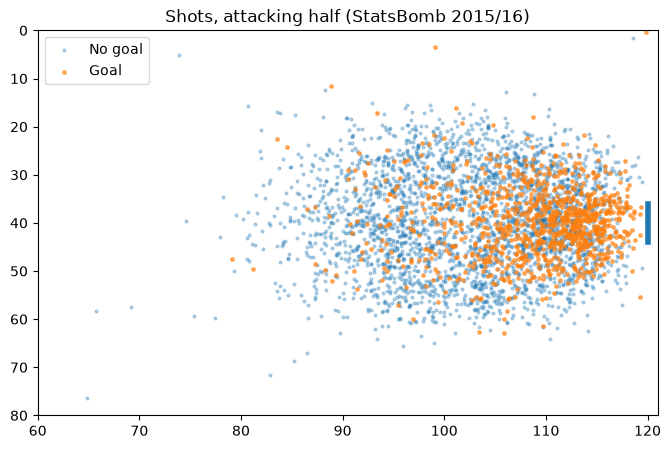

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
miss = op[op.is_goal == 0].sample(3000, random_state=1)
goal = op[op.is_goal == 1].sample(1000, random_state=1)
ax.scatter(miss.x, miss.y, s=4, alpha=0.3, label="No goal")
ax.scatter(goal.x, goal.y, s=6, alpha=0.6, label="Goal")
ax.plot([120, 120], [36, 44], linewidth=4)
ax.set_xlim(60, 121)
ax.set_ylim(0, 80)
ax.invert_yaxis()
ax.legend()
ax.set_title("Shots, attacking half (StatsBomb 2015/16)")

### StatsBomb's xG as a reference

In [6]:
print(op["is_goal"].sum(), round(op["statsbomb_xg"].sum(), 1))

3651 3515.9
